In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

data = []
current_movie = None

with open("combined_data_1.txt", "r") as file:
    for line in file:
        line = line.strip()

        if line.endswith(":"):
            current_movie = int(line[:-1])

        else:
            user_id, rating, date = line.split(",")

            data.append([
                int(user_id),
                current_movie,
                int(rating),
                date
            ])

df = pd.DataFrame(
    data,
    columns=["UserID", "MovieID", "Rating", "Date"]
)

print(df.head())

    UserID  MovieID  Rating        Date
0  1488844        1       3  2005-09-06
1   822109        1       5  2005-05-13
2   885013        1       4  2005-10-19
3    30878        1       4  2005-12-26
4   823519        1       3  2004-05-03


In [4]:
df.to_csv("netflix_ratings_1.csv", index=False)

In [11]:
df_sample = df.sample(500000, random_state=42)

In [6]:
df.shape

(24053764, 4)

In [12]:
df_sample.shape

(500000, 4)

In [8]:
for size in [500_000, 1_000_000, 5_000_000]:
    sample = df.sample(size, random_state=42)

    print(
        size,
        sample['UserID'].nunique(),
        sample['MovieID'].nunique()
    )

500000 213833 4399
1000000 284313 4486
5000000 415570 4499


## 1.Dataset Overview

In [14]:
n_users = df_sample['UserID'].nunique()
n_movies = df_sample['MovieID'].nunique()
n_ratings = len(df_sample)

print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")

Number of users: 213833
Number of movies: 4399
Number of ratings: 500000


## 2.Rating Distribution 

<Axes: xlabel='Rating', ylabel='count'>

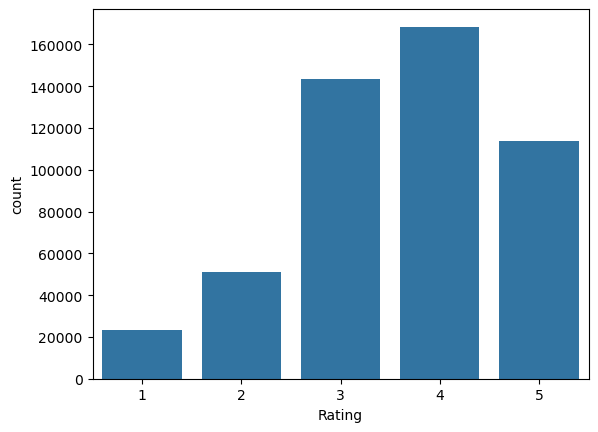

In [15]:
sns.countplot(
    x='Rating',
    data=df_sample
)

### Observations

- Rating 4 is the most common rating.
- Most ratings lie between 3 and 5.
- Low ratings are comparatively rare.

### Key Insight

- Users generally provide positive feedback, indicating a positive rating bias.

## 3.Average Rating Per User

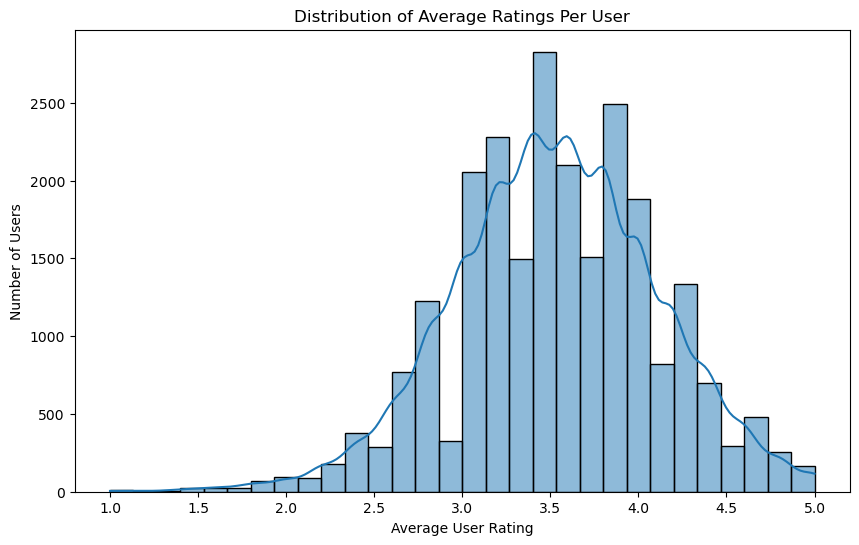

In [79]:
user_counts = df_sample.groupby('UserID')['Rating'].count()

active_users = user_counts[user_counts >= 5].index

user_avg = df_sample[df_sample['UserID'].isin(active_users)].groupby(
    'UserID'
)['Rating'].mean()

plt.figure(figsize=(10, 6))

sns.histplot(user_avg, bins=30, kde=True)

plt.title("Distribution of Average Ratings Per User")
plt.xlabel("Average User Rating")
plt.ylabel("Number of Users")

plt.show()

### Observations

- Most users have an average rating between 3.0 and 4.0.
- The distribution peaks around 3.5-3.8, indicating that users generally rate movies positively.
- Very few users consistently assign extremely low or extremely high ratings.
- The distribution is approximately bell-shaped with a slight skew toward higher ratings.

### Key Insight

- Active users tend to provide moderately positive ratings, with the majority of average ratings concentrated around 3.5-4.0. This suggests a positive rating bias in user behavior, which should be considered when developing recommendation models.

## 4.Average Rating Per Movie

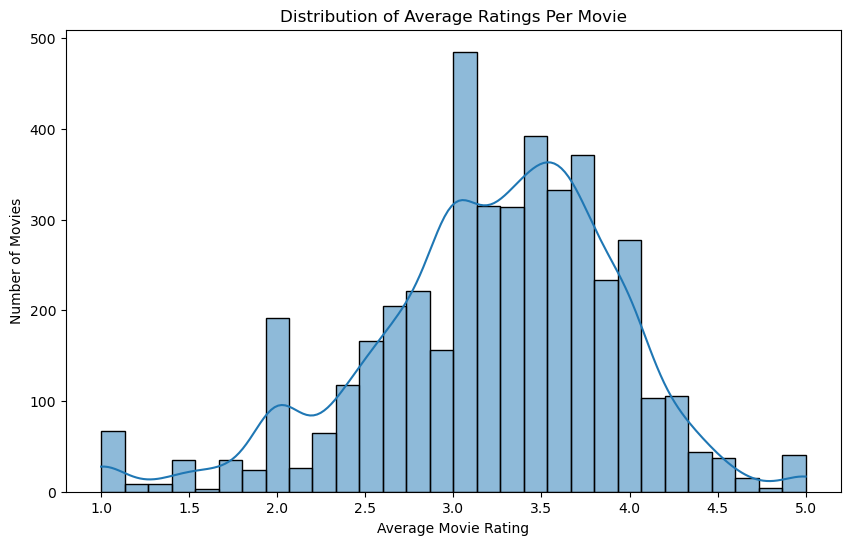

In [20]:
movie_avg = df_sample.groupby(
    'MovieID'
)['Rating'].mean()

plt.figure(figsize=(10, 6))
sns.histplot(movie_avg, bins=30, kde=True)

plt.title("Distribution of Average Ratings Per Movie")
plt.xlabel("Average Movie Rating")
plt.ylabel("Number of Movies")
plt.show()

### Observations

- Most movies have an average rating between 3.0 and 4.0.
- The distribution peaks around 3.4-3.8, indicating that the majority of movies receive moderately positive ratings.
- Very few movies have extremely low average ratings (below 2.0) or extremely high average ratings (above 4.5).
- The distribution is approximately bell-shaped, suggesting that most movies receive average ratings close to the overall mean.

### Key Insight

- Most movies are rated positively by users, with average ratings concentrated around 3.0-4.0. The relatively small number of extremely high-rated or low-rated movies indicates that user opinions are generally balanced, making personalized recommendation techniques necessary to distinguish between movies with similar average ratings.

## 5.Most Popular Movies

In [29]:
movie_titles = pd.read_csv(
    "movie_titles.csv",
    header=None,
    names=["MovieID", "Year", "Title"],
    encoding="latin-1",
    engine="python",
    on_bad_lines="skip"
)

In [30]:
movie_titles.head()

,MovieID,Year,Title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


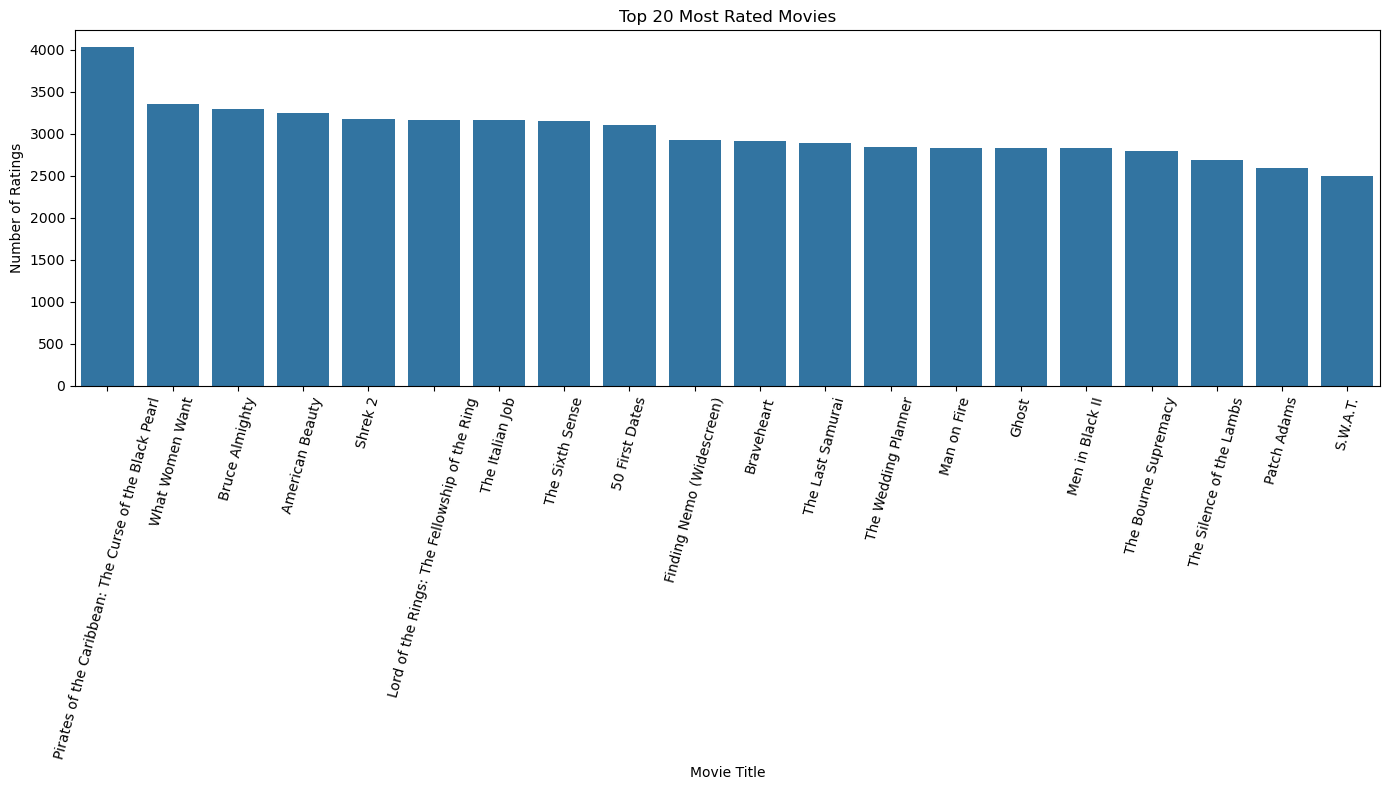

In [80]:
movie_rating_counts = (
    df_sample.groupby('MovieID')['Rating']
    .count()
    .reset_index(name='RatingCount')
)

top_20 = (
    movie_rating_counts
    .merge(movie_titles, on='MovieID')
    .sort_values('RatingCount', ascending=False)
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=top_20,
    x='Title',
    y='RatingCount'
)

plt.title("Top 20 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

### Observations

- "Pirates of the Caribbean: The Curse of the Black Pearl" received the highest number of ratings among all movies in the sample.
- Popular blockbuster movies such as "Shrek 2", "Finding Nemo", "The Sixth Sense", and "The Lord of the Rings" appear among the most frequently rated titles.
- The difference in rating counts between the most popular and least popular movies in the top 20 is noticeable but not extremely large.
- The top-rated-by-count movies are mostly well-known mainstream films, indicating strong user engagement with widely recognized content.
- The dominance of a few highly popular movies is an early indication of the Long Tail Effect, where a small number of movies attract a large share of user interactions.

### Key Insight

- User interactions are concentrated around a relatively small set of highly popular movies. This popularity concentration suggests that blockbuster titles dominate user attention, while many other movies receive significantly fewer ratings.

## 6.Most Active Users

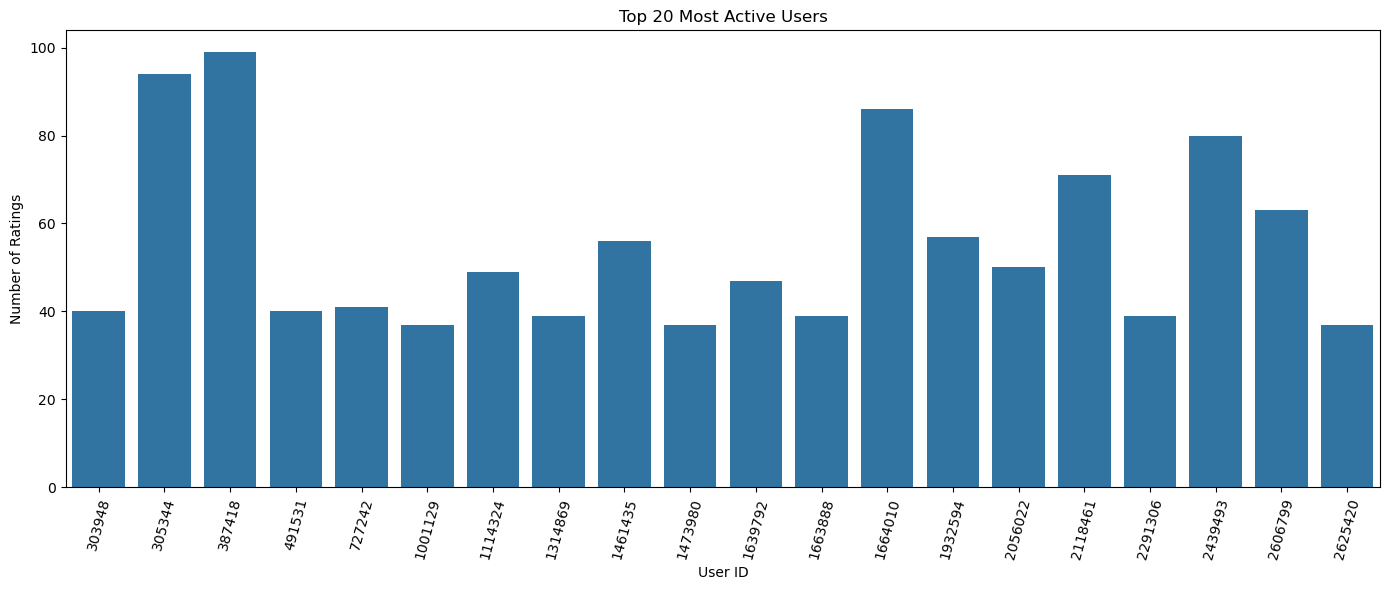

In [33]:
user_counts = df_sample.groupby(
    'UserID'
)['Rating'].count()

top_20 = user_counts.sort_values(ascending=False).head(20).reset_index(name='RatingCount')

plt.figure(figsize=(14,6))
sns.barplot(
    data=top_20,
    x='UserID',
    y='RatingCount'
)
plt.title("Top 20 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Observations

- A small group of users contributes significantly more ratings than the average user.
- The most active user in the sample has submitted nearly 100 ratings.
- Several users have rating counts substantially higher than the rest of the dataset.
- User activity is unevenly distributed, with a small fraction of users generating a large share of interactions.
- The presence of highly active users suggests that recommendation models may learn user preferences more effectively for these users compared to users with only a few ratings.

### Key Insight

- The dataset exhibits user activity imbalance, where a small number of highly active users contribute disproportionately to the rating data. Such users provide rich information for recommendation models, while less active users present a greater challenge due to limited interaction history.

## 7.Long Tail Analysis

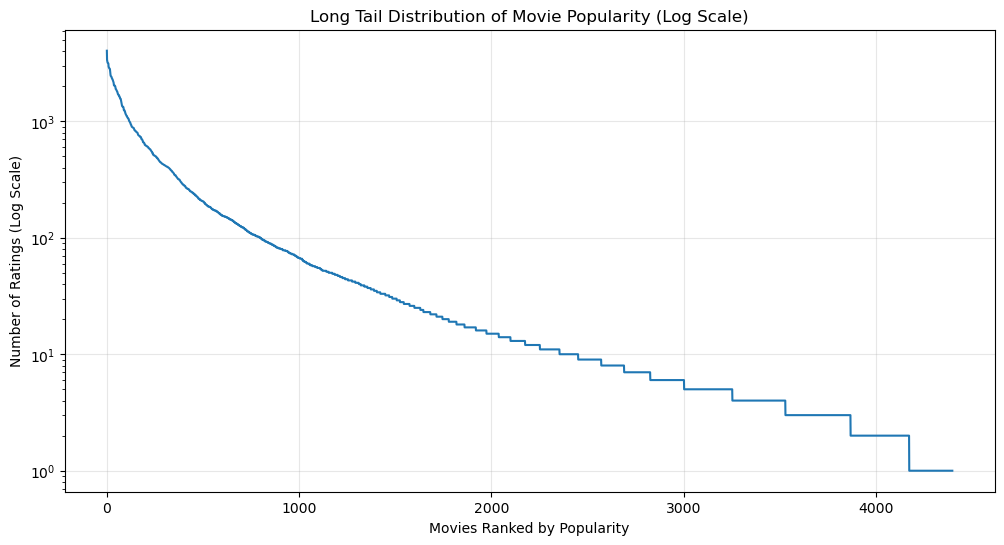

In [34]:
movie_counts = df_sample.groupby('MovieID')['Rating'].count()

movie_counts_sorted = movie_counts.sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

plt.plot(
    range(len(movie_counts_sorted)),
    movie_counts_sorted.values
)

plt.yscale('log')

plt.title("Long Tail Distribution of Movie Popularity (Log Scale)")
plt.xlabel("Movies Ranked by Popularity")
plt.ylabel("Number of Ratings (Log Scale)")

plt.grid(alpha=0.3)

plt.show()

### Observations

- Movie popularity decreases rapidly as we move from the most popular movies to less popular ones.
- A small number of movies receive thousands of ratings, while the majority receive only a few ratings.
- The distribution follows a highly skewed pattern rather than a uniform distribution.
- A large portion of movies in the dataset receive fewer than 100 ratings, with some receiving only a handful of ratings.
- The steep decline in the popularity curve indicates that user engagement is concentrated among a small subset of movies, leading to an imbalance in available rating information across the catalog.

### Key Insight

- The dataset exhibits a strong Long Tail Effect, where a small number of blockbuster movies dominate user interactions while thousands of niche movies receive limited attention. This creates a significant challenge for recommendation systems, as models must accurately recommend both popular and less frequently rated movies.

## 8.Ratings Per user Distribution 

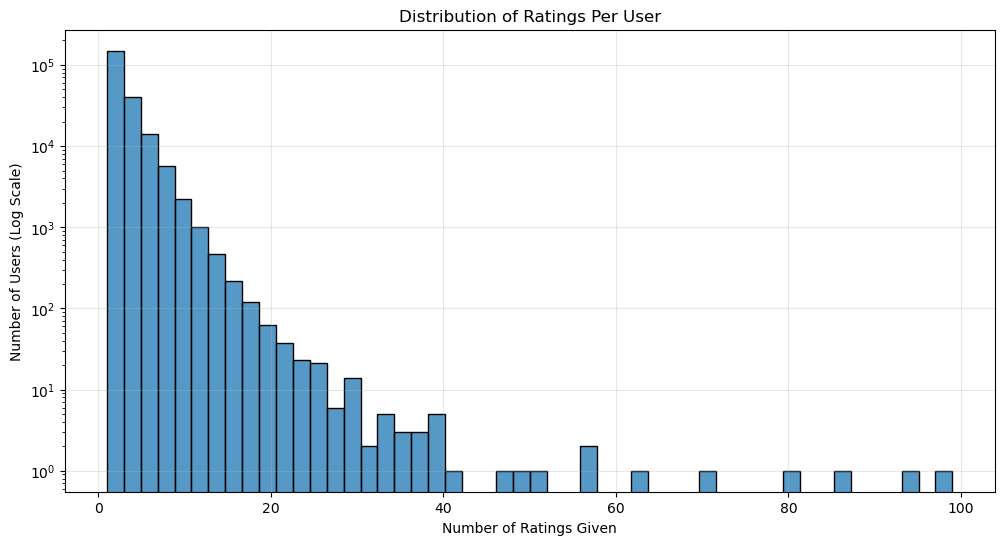

Average ratings per user: 2.338273325445558
Median ratings per user: 2.0
Maximum ratings by a user: 99


In [38]:
user_counts = df_sample.groupby('UserID')['Rating'].count()

plt.figure(figsize=(12,6))

sns.histplot(
    user_counts,
    bins=50
)

plt.yscale('log')

plt.title("Distribution of Ratings Per User")
plt.xlabel("Number of Ratings Given")
plt.ylabel("Number of Users (Log Scale)")

plt.grid(alpha=0.3)

plt.show()

print("Average ratings per user:", user_counts.mean())
print("Median ratings per user:", user_counts.median())
print("Maximum ratings by a user:", user_counts.max())

### Observations

- Most users have rated only a small number of movies, typically fewer than 10.
- The number of users decreases rapidly as the number of ratings given increases.
- Only a small fraction of users contribute a large number of ratings.
- A few highly active users have rated dozens of movies, with some approaching 100 ratings in the sample.
- The distribution exhibits a long-tail pattern, indicating that user engagement is concentrated among a relatively small subset of highly active users.

### Key Insight

- User activity is highly imbalanced, with the majority of users contributing only a few ratings while a small group of highly active users generates a disproportionate amount of interaction data. This imbalance can affect recommendation quality, especially for users with limited rating history.

## 9.Ratings per Movie Distribution 

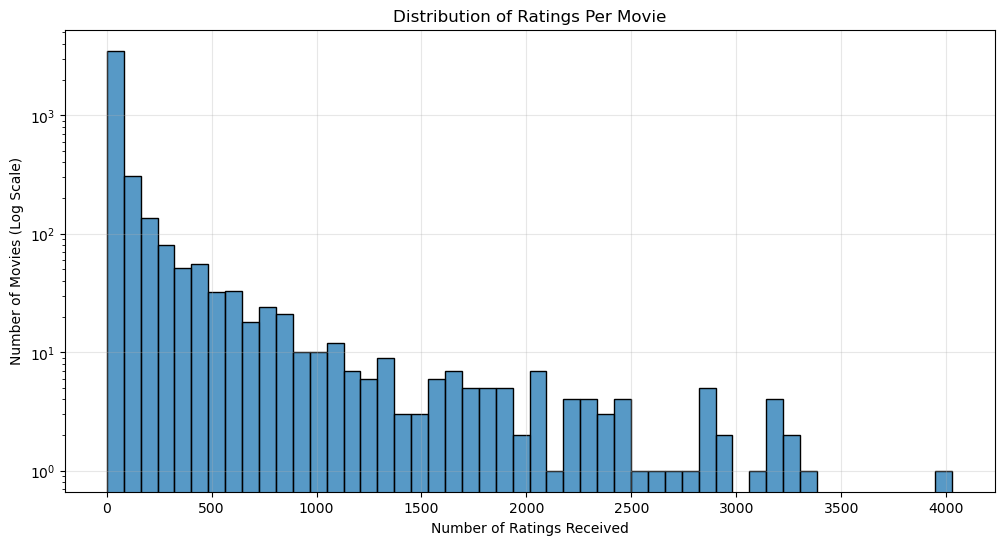

Average ratings per movie: 113.66219595362583
Median ratings per movie: 12.0
Maximum ratings received: 4029


In [40]:
movie_counts = df_sample.groupby('MovieID')['Rating'].count()

plt.figure(figsize=(12,6))

sns.histplot(
    movie_counts,
    bins=50
)

plt.yscale('log')

plt.title("Distribution of Ratings Per Movie")
plt.xlabel("Number of Ratings Received")
plt.ylabel("Number of Movies (Log Scale)")

plt.grid(alpha=0.3)

plt.show()

print("Average ratings per movie:", movie_counts.mean())
print("Median ratings per movie:", movie_counts.median())
print("Maximum ratings received:", movie_counts.max())

### Observations

- Most movies receive a relatively small number of ratings, with the median movie receiving only 12 ratings.
- A small number of highly popular movies receive thousands of ratings, with the most rated movie receiving 4,029 ratings.
- The large difference between the mean (113.66) and median (12) ratings per movie indicates a highly skewed distribution.
- Movie popularity is unevenly distributed, with a few blockbuster titles attracting a disproportionate share of user interactions.
- The distribution follows a long-tail pattern, with thousands of movies receiving relatively few ratings and only a handful achieving widespread popularity.

### Key Insight

- The dataset exhibits significant popularity imbalance, where a small number of movies dominate user attention while the majority of movies receive limited ratings. This imbalance creates challenges for recommendation systems, as popular movies have abundant interaction data whereas less popular movies have very little information available.

## 10.Sparsity Analysis 

In [41]:
# Number of unique users
n_users = df_sample['UserID'].nunique()

# Number of unique movies
n_movies = df_sample['MovieID'].nunique()

# Actual ratings present
actual_ratings = len(df_sample)

# Total possible ratings
possible_ratings = n_users * n_movies

# Sparsity %
sparsity = (
    1 - actual_ratings / possible_ratings
) * 100

print(f"Users: {n_users:,}")
print(f"Movies: {n_movies:,}")
print(f"Actual Ratings: {actual_ratings:,}")
print(f"Possible Ratings: {possible_ratings:,}")
print(f"Sparsity: {sparsity:.4f}%")

Users: 213,833
Movies: 4,399
Actual Ratings: 500,000
Possible Ratings: 940,651,367
Sparsity: 99.9468%


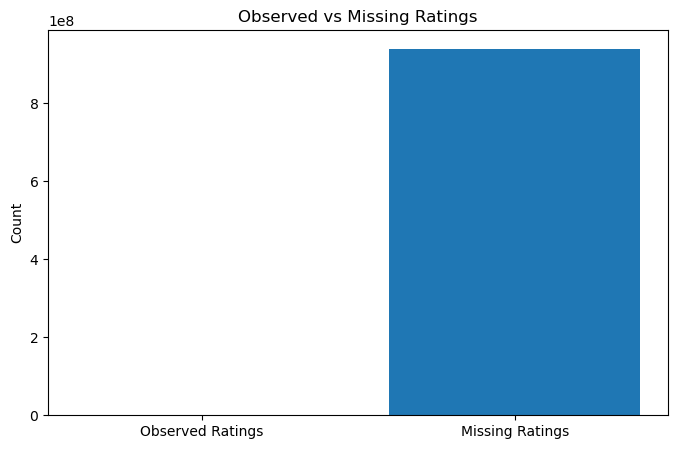

In [42]:
import matplotlib.pyplot as plt

values = [
    actual_ratings,
    possible_ratings - actual_ratings
]

labels = [
    "Observed Ratings",
    "Missing Ratings"
]

plt.figure(figsize=(8,5))

plt.bar(labels, values)

plt.title("Observed vs Missing Ratings")
plt.ylabel("Count")

plt.show()

### Observations

- The dataset contains 213,833 unique users and 4,399 unique movies.
- Out of 940.65 million possible user-movie interactions, only 500,000 ratings are observed.
- The user-movie matrix has an extremely high sparsity of 99.9468%.
- The number of missing ratings vastly exceeds the number of observed ratings, as shown in the visualization.
- Less than 0.1% of all possible user-movie interactions are available, indicating that user preferences must be inferred from very limited information.

### Key Insight

- The dataset is extremely sparse, meaning that most users have rated only a tiny fraction of available movies. This lack of interaction data makes recommendation generation challenging and necessitates the use of advanced techniques such as collaborative filtering and matrix factorization.

## 11.User-Movie Interaction Matrix Visualization

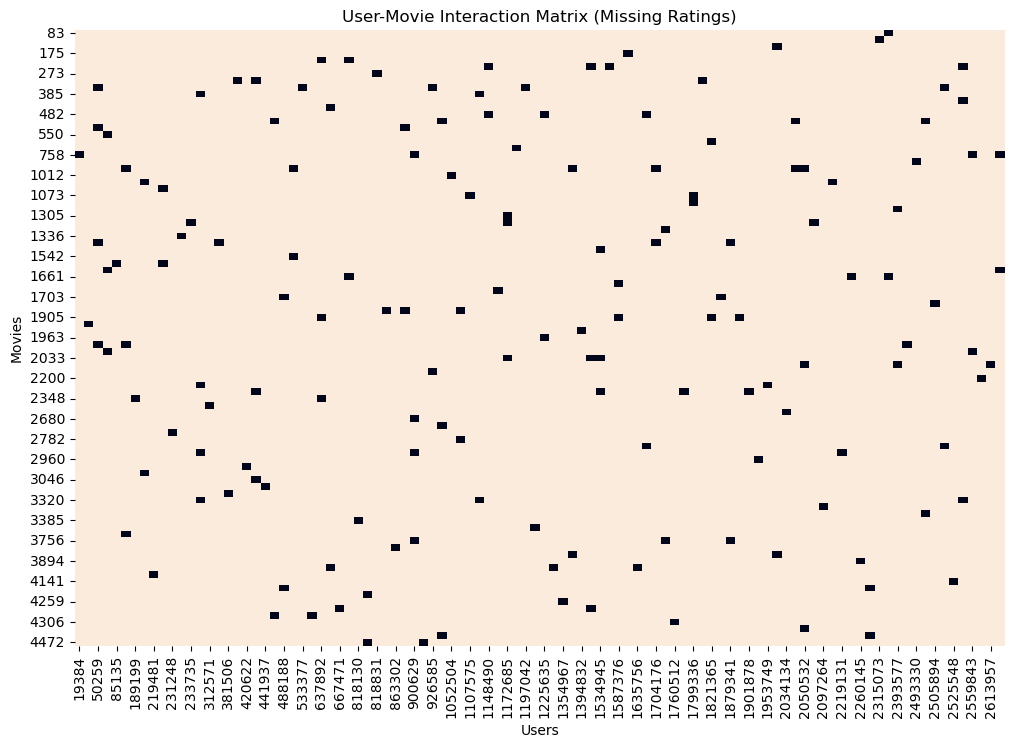

In [45]:
# Select a subset of users and movies
sample_users = df_sample['UserID'].unique()[:100]
sample_movies = df_sample['MovieID'].unique()[:100]

small_df = df_sample[
    (df_sample['UserID'].isin(sample_users))
    &
    (df_sample['MovieID'].isin(sample_movies))
]

# Create user-movie matrix
interaction_matrix = small_df.pivot_table(
    index='MovieID',
    columns='UserID',
    values='Rating'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    interaction_matrix.isnull(),
    cbar=False
)

plt.title("User-Movie Interaction Matrix (Missing Ratings)")

plt.xlabel("Users")
plt.ylabel("Movies")

plt.show()

### Observations

- The majority of cells in the user-movie interaction matrix are empty.
- Only a very small fraction of user-movie pairs contain ratings.
- The visual pattern confirms the extreme sparsity calculated in the previous section.

### Key Insight

- The interaction matrix is overwhelmingly sparse, indicating that most users rate only a tiny subset of available movies. Recommendation algorithms must therefore infer preferences from very limited observed interactions.

## 12.Rating Trends Over Time 

In [48]:
df_sample['Date'] = pd.to_datetime(df_sample['Date'])

### Ratings Per Year

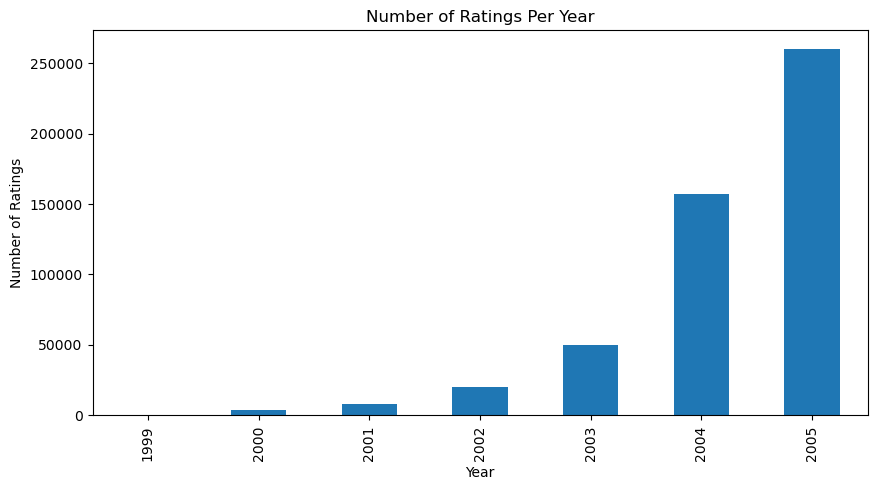

In [50]:
ratings_per_year = (
    df_sample
    .groupby(df_sample['Date'].dt.year)
    .size()
)

plt.figure(figsize=(10,5))

ratings_per_year.plot(
    kind='bar'
)

plt.title("Number of Ratings Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.show()

### Observations

- The number of ratings increases significantly over time.
- User activity grows rapidly between 2003 and 2005.
- The highest number of ratings is observed in 2005, indicating peak user engagement during this period.

### Key Insight

- The steady increase in rating activity suggests growing platform adoption and user participation over time.

### Ratings Per Month

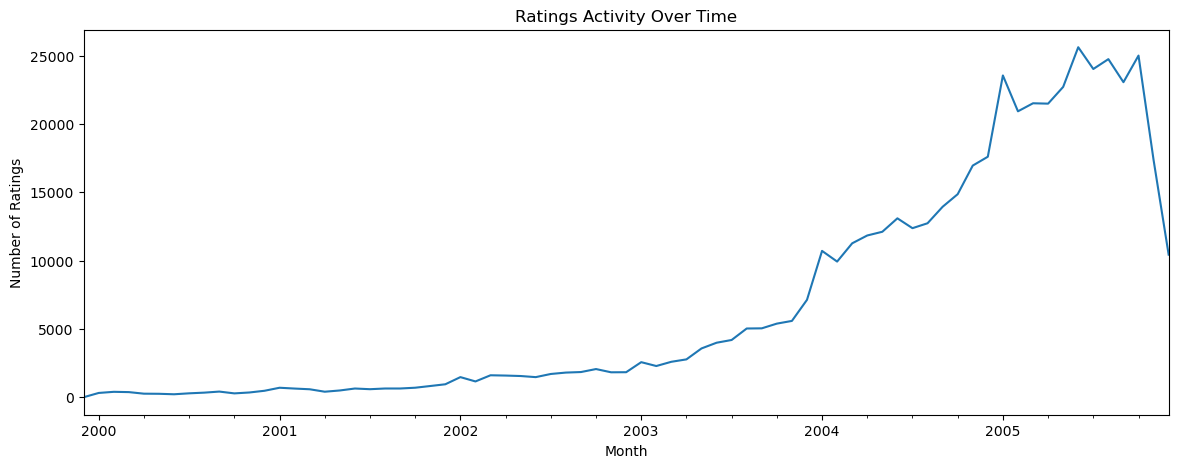

In [53]:
ratings_per_month = (
    df_sample
    .groupby(df_sample['Date'].dt.to_period('M'))
    .size()
)

plt.figure(figsize=(14,5))

ratings_per_month.plot()

plt.title("Ratings Activity Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Ratings")

plt.show()

### Observations

- Monthly rating activity shows a strong upward trend throughout the observed period.
- User engagement accelerates noticeably after 2003.
- Peak activity occurs during 2005, where monthly ratings reach their highest levels.
- The growth pattern appears exponential rather than linear, suggesting rapid expansion of the user base and rating activity.

### Key Insight

- User engagement grew consistently over time, indicating increasing platform usage and content consumption.

### Average Ratings Over Time 

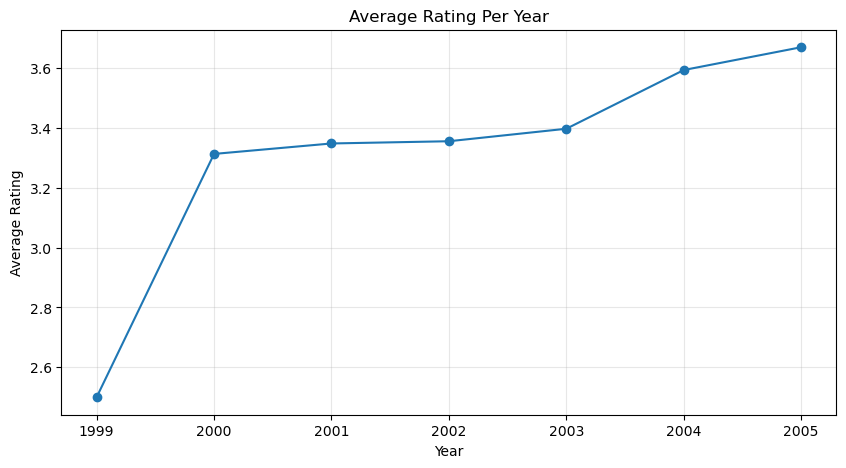

In [54]:
avg_rating_year = (
    df_sample
    .groupby(df_sample['Date'].dt.year)['Rating']
    .mean()
)

plt.figure(figsize=(10,5))

avg_rating_year.plot(
    marker='o'
)

plt.title("Average Rating Per Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.show()

### Observations

- Average ratings remain relatively stable between 2000 and 2003.
- A gradual increase in average ratings is observed after 2003.
- The highest average rating is recorded in 2005.
- The increase in average ratings may suggest improving user satisfaction, changes in content quality, or evolving user rating habits.

### Key Insight

- While user activity increased dramatically over time, average ratings remained relatively consistent, indicating stable user rating behavior across years.

## 13.Movie release Year Analysis

### Movies Realeased Per Year

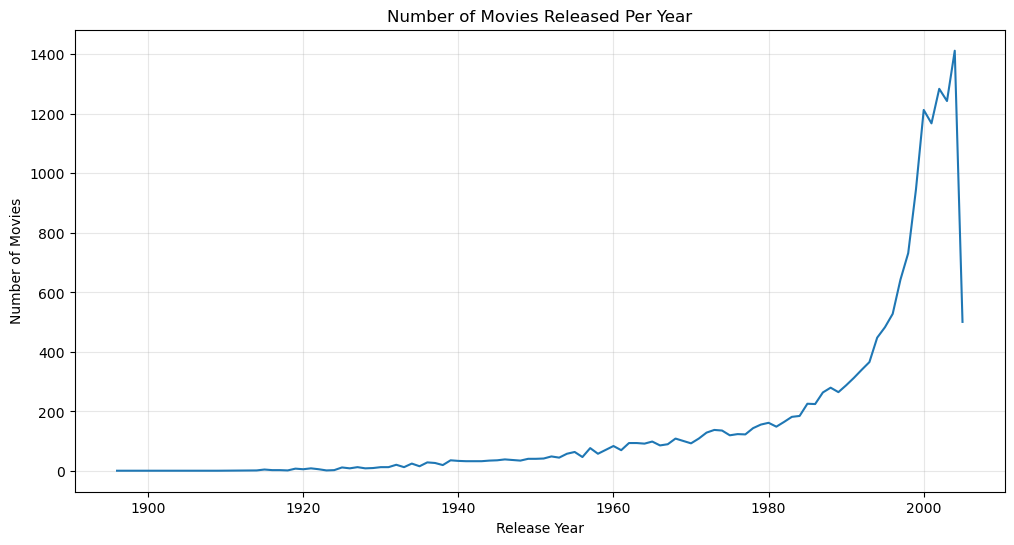

In [55]:
movies_per_year = (
    movie_titles['Year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

movies_per_year.plot()

plt.title("Number of Movies Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.grid(alpha=0.3)

plt.show()

### Observations

- The number of movies released increases steadily over time.
- A rapid growth in movie releases is observed after the 1990s.
- The highest number of movies in the dataset were released during the early 2000s.
- The drop in the final year is likely due to incomplete data collection rather than an actual decline in movie production.

### Key Insight

- The movie industry experienced substantial growth over time, resulting in a larger catalog of content available for recommendation.

### Ratings by Release Year

In [56]:
ratings_with_movies = df_sample.merge(movie_titles, on='MovieID')

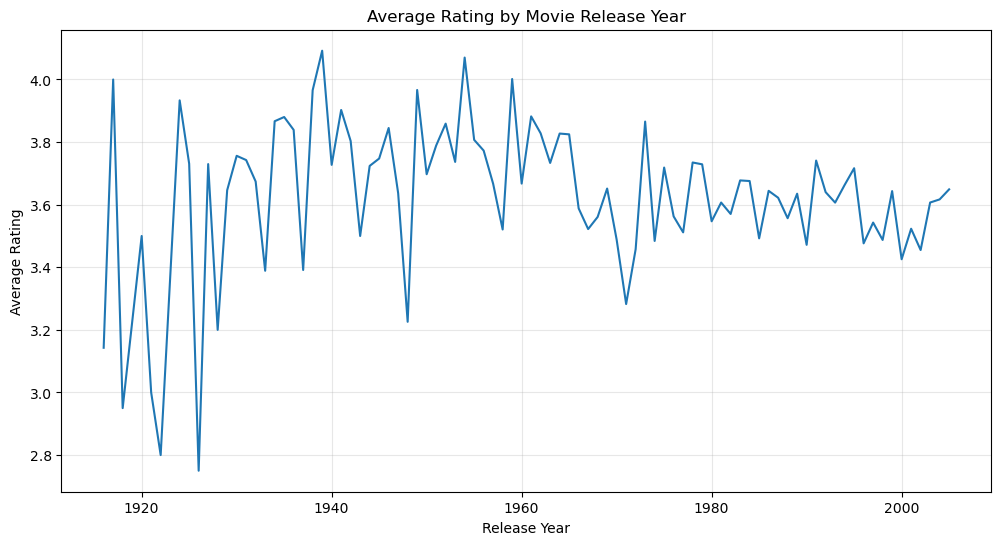

In [60]:
avg_rating_year = ratings_with_movies.groupby('Year')['Rating'].mean()

plt.figure(figsize=(12,6))

avg_rating_year.plot()

plt.title("Average Rating by Movie Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.show()

### Observations

- Average movie ratings remain relatively stable across decades.
- Most yearly average ratings fall between 3.4 and 3.8.
- No strong upward or downward trend is observed in movie quality based on user ratings.
- Some fluctuations in older years are likely caused by a smaller number of movies available from those periods.
- Users appear to evaluate movies similarly across different eras, suggesting rating behavior remains stable over time.

### Key Insight

- Although the number of movies increased dramatically over time, average user satisfaction remained fairly consistent.

### Most Popular Release Years 

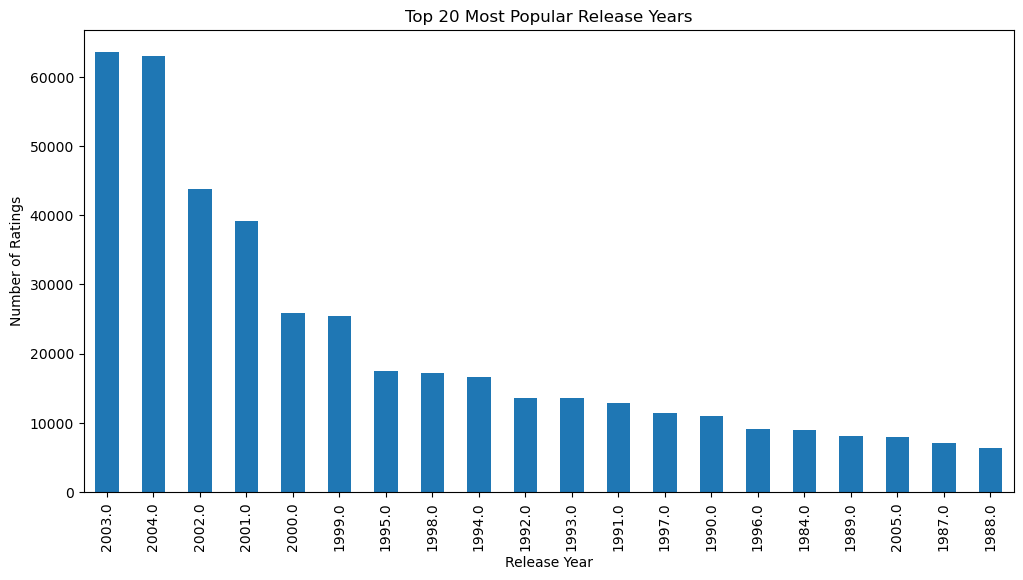

In [61]:
ratings_per_year = (
    ratings_with_movies
    .groupby('Year')
    .size()
)

plt.figure(figsize=(12,6))

ratings_per_year.sort_values(
    ascending=False
).head(20).plot(
    kind='bar'
)

plt.title("Top 20 Most Popular Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Ratings")

plt.show()

### Observations

- Movies released between 1999 and 2004 dominate the popularity rankings.
- Release years 2003 and 2004 receive the highest number of ratings.
- Recent movies generally attract more user interactions than older movies.
- Several older release years still appear in the top rankings, indicating the long-term popularity of classic films.

### Key Insight

- Users tend to interact more with relatively recent movies, creating a recency bias in rating activity.

## 14.Popularity vs Rating Correlation 

In [62]:
movie_stats = (
    df_sample.groupby('MovieID')['Rating']
    .agg(['count', 'mean'])
    .reset_index()
)

movie_stats.columns = [
    'MovieID',
    'RatingCount',
    'AverageRating'
]

movie_stats.head()

,MovieID,RatingCount,AverageRating
0,1,13,3.769231
1,2,2,5.000000
2,3,37,3.837838
3,4,3,2.333333
4,5,25,3.840000


In [65]:
movie_stats_filtered = movie_stats[movie_stats['RatingCount'] >= 100]

In [81]:
corr = movie_stats_filtered[
    'RatingCount'
].corr(
    movie_stats_filtered['AverageRating']
)

print(f"Correlation: {corr:.3f}")

Correlation: 0.187


There is only a weak positive correlation between popularity and average rating, meaning popularity explains very little of a movie's rating quality.

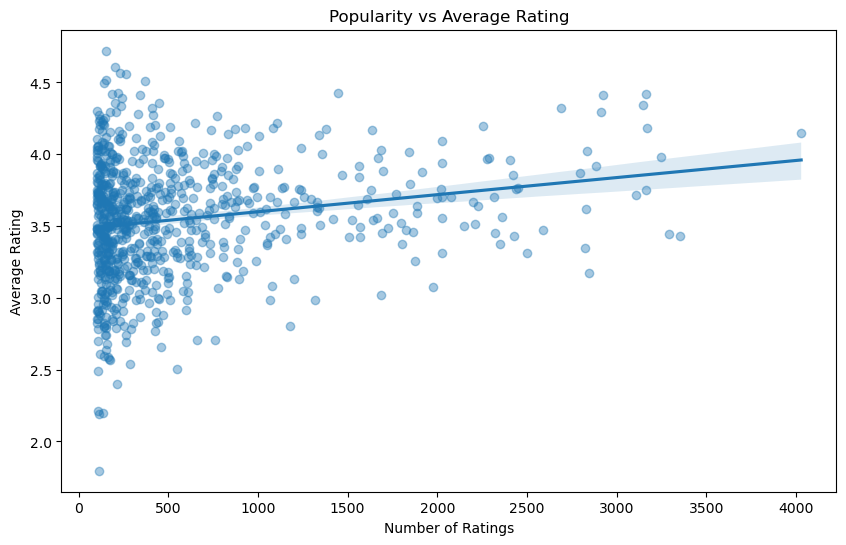

In [70]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=movie_stats_filtered,
    x='RatingCount',
    y='AverageRating',
    scatter_kws={'alpha':0.4}
)

plt.title("Popularity vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.show()

### Observations

- The scatter plot shows a weak positive relationship between movie popularity and average rating.
- Movies with a higher number of ratings tend to have slightly higher average ratings.
- The computed correlation coefficient is 0.187, indicating only a weak positive correlation.
- Many less popular movies exhibit both very high and very low ratings, showing greater rating variability.
- Popular movies are concentrated around ratings of 3.5–4.2, suggesting more stable user opinions.

### Top Rated Movies 

In [71]:
top_rated = movie_stats_filtered.sort_values(
    'AverageRating',
    ascending=False
).head(10)

top_rated

,MovieID,RatingCount,AverageRating
3375,3456,154,4.720779
2053,2102,204,4.607843
3364,3444,231,4.567100
1435,1476,261,4.559387
3842,3928,153,4.516340
2111,2162,367,4.506812
4328,4427,140,4.492857
2065,2114,221,4.429864
3211,3290,1445,4.424221
2398,2452,3162,4.420936


### Most popular Movies

In [72]:
most_popular = movie_stats_filtered.sort_values(
    'RatingCount',
    ascending=False
).head(10)

most_popular

,MovieID,RatingCount,AverageRating
1861,1905,4029,4.146935
2102,2152,3356,3.429380
3776,3860,3294,3.447177
558,571,3249,3.979070
3851,3938,3170,4.183281
2398,2452,3162,4.420936
4333,4432,3162,3.749526
4212,4306,3146,4.341068
1915,1962,3107,3.716125
3875,3962,2926,4.415584


### Key Insight

- Popularity alone is not a strong indicator of movie quality.
- While highly rated movies often become popular, many popular movies receive only average ratings.
- Recommendation systems should consider both popularity and user preference rather than relying solely on rating counts.

### Advanced Insight

- Movies with few ratings are more likely to have extreme average ratings because of limited user feedback.
- As the number of ratings increases, average ratings become more reliable and tend to converge toward the overall mean.
- This phenomenon is known as the "small sample size bias" and is a key challenge in recommendation systems.

## 15.Top Rated Movies 

In [73]:
movie_stats.head()

,MovieID,RatingCount,AverageRating
0,1,13,3.769231
1,2,2,5.000000
2,3,37,3.837838
3,4,3,2.333333
4,5,25,3.840000


In [74]:
top_rated_movies = movie_stats[
    movie_stats['RatingCount'] >= 100
]

top_rated_movies = (
    top_rated_movies
    .merge(movie_titles, on='MovieID')
)

top_10_movies = (
    top_rated_movies
    .sort_values(
        by='AverageRating',
        ascending=False
    )
    .head(10)
)

top_10_movies[
    ['Title', 'AverageRating', 'RatingCount']
]

,Title,AverageRating,RatingCount
612,Lost: Season 1,4.720779,154
365,The Simpsons: Season 6,4.607843,204
609,Family Guy: Freakin' Sweet Collection,4.567100,231
248,Six Feet Under: Season 4,4.559387,261
702,Nip/Tuck: Season 2,4.516340,153
379,CSI: Season 1,4.506812,367
782,The West Wing: Season 3,4.492857,140
369,Firefly,4.429864,221
429,Lord of the Rings: The Fellowship of the Ring,4.420936,3162
361,Buffy the Vampire Slayer: Season 6,4.417112,187


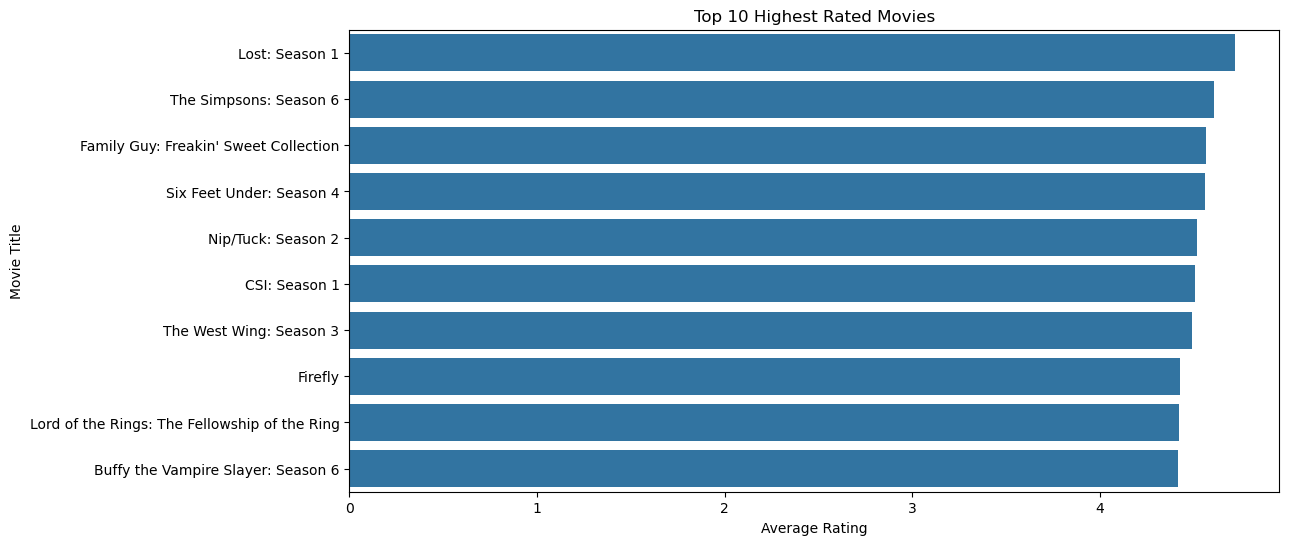

In [75]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_movies,
    x='AverageRating',
    y='Title'
)

plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.show()

### Observations

- All movies in the ranking have received at least 100 ratings, making their average ratings statistically more reliable.
- "Lost: Season 1" has the highest average rating in the dataset (4.72).
- Several TV series and TV show seasons dominate the top-rated list.
- Most top-rated titles have average ratings above 4.4, indicating extremely positive user reception.
- The rating difference between the top 10 titles is relatively small, showing strong competition among highly rated content.

### Key Insight

- Highly rated content is not limited to blockbuster movies; television series and season-based content receive some of the strongest user ratings.
- Applying a minimum rating-count threshold helps eliminate small-sample bias and produces a more trustworthy ranking of top-rated titles.

### Advanced Insight

- Some movies achieve very high ratings despite having moderate popularity, demonstrating that popularity and quality are not the same thing.
- For example, several titles in the top-rated list have only 150–300 ratings but still outperform more popular movies in average rating.
- This supports the earlier finding that popularity and rating quality have only a weak positive correlation (0.187).

### Relevance to Recommendation Systems

- Recommending only the most popular movies may overlook many high-quality titles.
- Recommendation systems should balance popularity and rating quality to provide better personalized suggestions.
- This motivates the use of collaborative filtering and hybrid recommendation approaches.

## 16. Lowest Rated Movies 

In [77]:
low_rated_movies = movie_stats[
    movie_stats['RatingCount'] >= 100
]

low_rated_movies = (
    low_rated_movies
    .merge(movie_titles, on='MovieID')
)

bottom_10_movies = (
    low_rated_movies
    .sort_values(
        by='AverageRating',
        ascending=True
    )
    .head(10)
)

bottom_10_movies[
    ['Title', 'AverageRating', 'RatingCount']
]

,Title,AverageRating,RatingCount
529,House of the Dead,1.796460,113
255,Monkeybone,2.194690,113
196,Dr. T & the Women,2.195489,133
637,Cop and a Half,2.209524,105
728,The Flintstones,2.402844,211
399,People I Know,2.490566,106
469,Solaris,2.507273,550
701,Le Divorce,2.541958,286
453,Abandon,2.563953,172
304,A Dirty Shame,2.571429,168


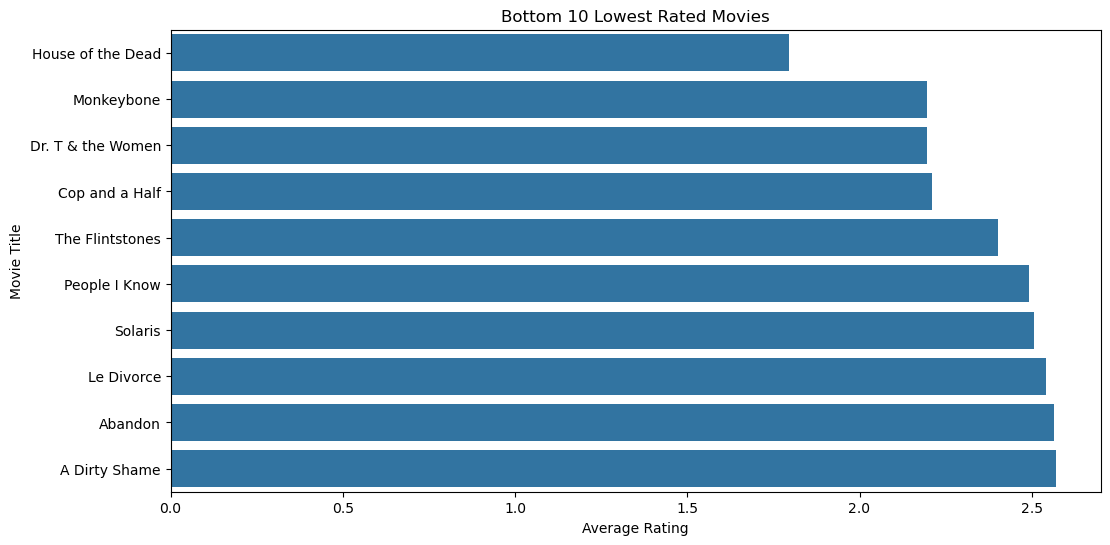

In [78]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom_10_movies,
    x='AverageRating',
    y='Title'
)

plt.title("Bottom 10 Lowest Rated Movies")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.show()

### Observations

- "House of the Dead" is the lowest-rated title in the dataset, with an average rating of only 1.80 despite receiving over 100 ratings.
- All movies in the bottom 10 list have average ratings below 2.6, indicating strong negative audience reception.
- The ratings of the lowest-ranked movies are significantly lower than the overall dataset average (approximately 3.5–3.7).
- Several poorly rated movies still received more than 100 ratings, suggesting that low ratings are not simply due to a lack of viewer engagement.
- The difference between the lowest-rated movie and the tenth-lowest-rated movie is relatively small, indicating consistent dissatisfaction across these titles.

### Key Insight

- Applying a minimum threshold of 100 ratings ensures that these low ratings are based on a meaningful number of user opinions rather than a small sample size.
- This provides a reliable list of genuinely unpopular or poorly received movies.

### Comparison with Top Rated Movies

- While the highest-rated movies achieved average ratings above 4.4, the lowest-rated movies remain below 2.6.
- The rating gap of nearly 3 points highlights the large variation in user preferences across different titles.
- Unlike the top-rated list, which was dominated by television series and critically acclaimed content, the lowest-rated list consists primarily of titles that failed to satisfy audiences.

### Relevance to Recommendation Systems

- Identifying consistently low-rated movies is valuable for recommendation systems because such titles can be deprioritized when generating suggestions.
- User feedback helps distinguish content that is broadly appreciated from content that receives consistently negative reactions.
- This demonstrates how collaborative filtering can leverage collective user opinions to improve recommendation quality.